#  Deep Learning-Based Road Damage Detection System
### Using YOLO variants Object Detection for Road Infrastructure Monitoring

**Course:** Deep Learning  
**Date:** January 2026

---

## Table of Contents
1. [Setup & Installation](#1-setup--installation)
2. [Dataset Preparation (60% Subset)](#2-dataset-preparation)
3. [Data Exploration & Visualization](#3-data-exploration)
4. [Model Training with Auto-Save](#4-model-training)
5. [Evaluation & Metrics](#5-evaluation--metrics)
6. [Predictions with Bounding Boxes](#6-predictions-with-bounding-boxes)
7. [Error Analysis](#7-error-analysis)

---
## 1. Setup & Installation <a id='1-setup--installation'></a>

In [ ]:
print("Road Damage Detection")

Road Damage Detection


In [3]:
# Install required packages
!pip install ultralytics -q
!pip install opencv-python-headless -q
!pip install albumentations -q

print("✅ Installation complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 kB 4.4 MB/s eta 0:00:00
✅ Installation complete!


In [4]:
# Import libraries
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
from pathlib import Path
from collections import Counter
import yaml
import warnings
warnings.filterwarnings('ignore')

# Ultralytics YOLOv8
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Libraries imported successfully!")
print(f"Random seed set to: {SEED}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✅ Libraries imported successfully!
Random seed set to: 42


In [5]:
# Check GPU availability (important for Kaggle)
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"GPUs available: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("⚠️ No GPU detected. Training will be slower on CPU.")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.64 GB
GPUs available: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


---
## 2. Dataset Preparation () <a id='2-dataset-preparation'></a>

We'll use 60% of the Road Damage Dataset to reduce training time while maintaining good performance.

In [6]:
# Configuration
CONFIG = {
    'dataset_path': '/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data',  # Kaggle dataset path
    'working_dir': '/kaggle/working',
    'subset_ratio': 1,  # Not use 60% of the data
    'train_ratio': 0.70,   # 70% for training
    'val_ratio': 0.20,     # 20% for validation  
    'test_ratio': 0.10,    # 10% for testing
    'image_size': 640,
    'batch_size': 16,
    'epochs': 100,
    'model_variant': 'yolov8s',  # Options: yolov8n, yolov8s, yolov8m
    'save_period': -1,  # Save checkpoint every 5 epochs, edited to -1 to disable
    'device': [0, 1]
}

# Class names
CLASS_NAMES = {0: 'Pothole', 1: 'Crack', 2: 'Manhole'}
CLASS_COLORS = {0: 'red', 1: 'blue', 2: 'green'}

print("📋 Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

📋 Configuration:
   dataset_path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data
   working_dir: /kaggle/working
   subset_ratio: 1
   train_ratio: 0.7
   val_ratio: 0.2
   test_ratio: 0.1
   image_size: 640
   batch_size: 16
   epochs: 100
   model_variant: yolov8s
   save_period: -1
   device: [0, 1]


In [7]:
# Find the correct dataset path
import os

# List everything in the input directory
print("📁 Contents of /kaggle/input/:")
print("-" * 50)

for item in os.listdir('/kaggle/input/'):
    print(f"📂 {item}")
    
    # Go one level deeper
    subpath = f'/kaggle/input/{item}'
    if os.path.isdir(subpath):
        for sub_item in os.listdir(subpath)[:10]:  # First 10 items
            full_path = f'{subpath}/{sub_item}'
            if os.path.isdir(full_path):
                print(f"   📂 {sub_item}/")
            else:
                print(f"   📄 {sub_item}")

📁 Contents of /kaggle/input/:
--------------------------------------------------
📂 road-damage-dataset-potholes-cracks-and-manholes
   📂 data/


In [8]:
# Explore the dataset structure
dataset_path = Path(CONFIG['dataset_path'])

print("📁 Dataset structure:")
for item in dataset_path.rglob('*'):
    if item.is_dir():
        print(f"  📂 {item.relative_to(dataset_path)}")

# Count images and labels
image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
all_images = [f for f in dataset_path.rglob('*') if f.suffix.lower() in image_extensions]
all_labels = list(dataset_path.rglob('*.txt'))

print(f"\n📊 Dataset Statistics:")
print(f"   Total images found: {len(all_images)}")
print(f"   Total label files found: {len(all_labels)}")

📁 Dataset structure:
  📂 labels
  📂 images
  📂 labels-YOLO

📊 Dataset Statistics:
   Total images found: 2009
   Total label files found: 4018


In [9]:
def create_subset_dataset(source_path, dest_path, subset_ratio=1, train_ratio=0.7, val_ratio=0.2):
    """
    Create a subset of the dataset with proper train/val/test splits.
    """
    source_path = Path(source_path)
    dest_path = Path(dest_path)
    
    # Create destination directories
    for split in ['train', 'val', 'test']:
        (dest_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (dest_path / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    # Find all image-label pairs
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    image_label_pairs = []
    
    # Try to find images folder
    images_dirs = list(source_path.rglob('images')) + [source_path]
    
    for images_dir in images_dirs:
        for img_path in images_dir.glob('*'):
            if img_path.suffix.lower() in image_extensions:
                # Try to find corresponding label
                label_name = img_path.stem + '.txt'
                
                # Check multiple possible label locations
                possible_label_paths = [
                    img_path.parent / label_name,
                    img_path.parent.parent / 'labels' / label_name,
                    source_path / 'labels' / label_name,
                ]
                
                for label_path in possible_label_paths:
                    if label_path.exists():
                        image_label_pairs.append((img_path, label_path))
                        break
    
    # Remove duplicates
    image_label_pairs = list(set(image_label_pairs))
    print(f"Found {len(image_label_pairs)} image-label pairs")
    
    # Shuffle and take subset
    random.shuffle(image_label_pairs)
    subset_size = int(len(image_label_pairs) * subset_ratio)
    subset_pairs = image_label_pairs[:subset_size]
    
    print(f"Using {len(subset_pairs)} pairs ({subset_ratio*100:.0f}% subset)")
    
    # Split into train/val/test
    n_train = int(len(subset_pairs) * train_ratio)
    n_val = int(len(subset_pairs) * val_ratio)
    
    train_pairs = subset_pairs[:n_train]
    val_pairs = subset_pairs[n_train:n_train + n_val]
    test_pairs = subset_pairs[n_train + n_val:]
    
    splits = {'train': train_pairs, 'val': val_pairs, 'test': test_pairs}
    
    # Copy files
    stats = {}
    for split_name, pairs in splits.items():
        for img_path, label_path in pairs:
            # Copy image
            dest_img = dest_path / split_name / 'images' / img_path.name
            shutil.copy2(img_path, dest_img)
            
            # Copy label
            dest_label = dest_path / split_name / 'labels' / label_path.name
            shutil.copy2(label_path, dest_label)
        
        stats[split_name] = len(pairs)
        print(f"   {split_name}: {len(pairs)} samples")
    
    return stats

# Create subset dataset
print("\n🔄 Creating subset dataset...")
subset_path = Path(CONFIG['working_dir']) / 'road_damage_subset'

if subset_path.exists():
    shutil.rmtree(subset_path)

dataset_stats = create_subset_dataset(
    CONFIG['dataset_path'],
    subset_path,
    subset_ratio=CONFIG['subset_ratio'],
    train_ratio=CONFIG['train_ratio'],
    val_ratio=CONFIG['val_ratio']
)

print("\n✅ Subset dataset created successfully!")


🔄 Creating subset dataset...
Found 2009 image-label pairs
Using 2009 pairs (100% subset)
   train: 1406 samples
   val: 401 samples
   test: 202 samples

✅ Subset dataset created successfully!


In [10]:
# Create YAML configuration file for YOLO
yaml_config = {
    'path': str(subset_path),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': CLASS_NAMES
}

yaml_path = subset_path / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False)

print("📄 Created data.yaml:")
print("-" * 40)
with open(yaml_path, 'r') as f:
    print(f.read())

📄 Created data.yaml:
----------------------------------------
names:
  0: Pothole
  1: Crack
  2: Manhole
path: /kaggle/working/road_damage_subset
test: test/images
train: train/images
val: val/images



---
## 3. Data Exploration & Visualization <a id='3-data-exploration'></a>

In [11]:
def analyze_labels(labels_dir):
    """
    Analyze label distribution in the dataset.
    """
    labels_dir = Path(labels_dir)
    class_counts = Counter()
    bbox_sizes = {0: [], 1: [], 2: []}
    
    for label_file in labels_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    width = float(parts[3])
                    height = float(parts[4])
                    area = width * height
                    
                    class_counts[class_id] += 1
                    if class_id in bbox_sizes:
                        bbox_sizes[class_id].append(area)
    
    return class_counts, bbox_sizes

# Analyze training set
train_labels_dir = subset_path / 'train' / 'labels'
class_counts, bbox_sizes = analyze_labels(train_labels_dir)

print("📊 Training Set Class Distribution:")
print("-" * 40)
total = sum(class_counts.values())
for class_id, count in sorted(class_counts.items()):
    percentage = (count / total) * 100
    print(f"   {CLASS_NAMES[class_id]}: {count} ({percentage:.1f}%)")
print(f"   Total annotations: {total}")

📊 Training Set Class Distribution:
----------------------------------------
   Pothole: 893 (26.7%)
   Crack: 1791 (53.5%)
   Manhole: 662 (19.8%)
   Total annotations: 3346


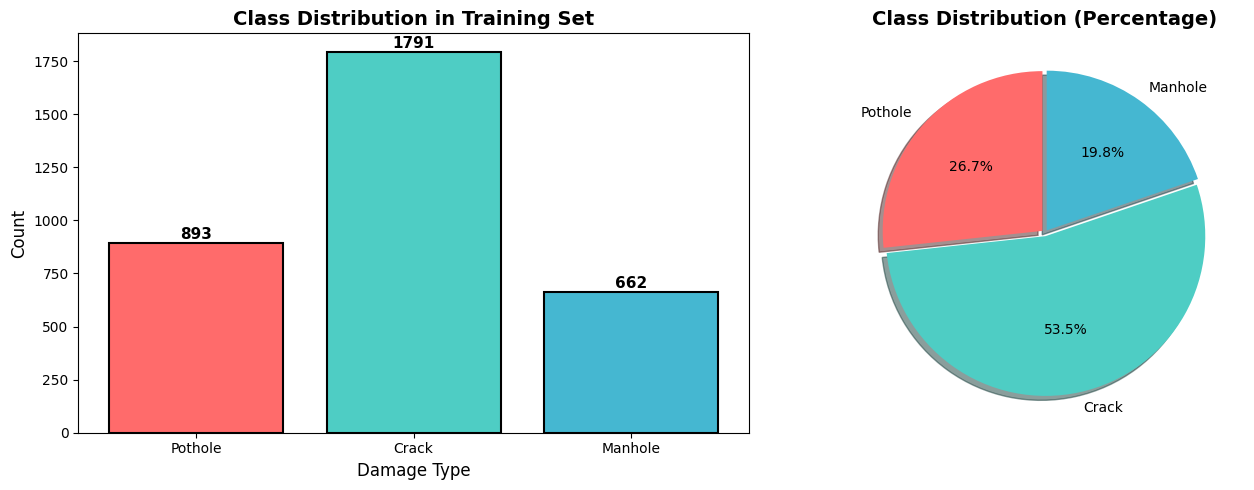


💾 Saved: class_distribution.png


In [12]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class distribution
classes = [CLASS_NAMES[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax1 = axes[0]
bars = ax1.bar(classes, counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Damage Type', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
ax2.pie(counts, labels=classes, autopct='%1.1f%%', colors=colors,
        explode=[0.02]*len(classes), shadow=True, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CONFIG['working_dir']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: class_distribution.png")

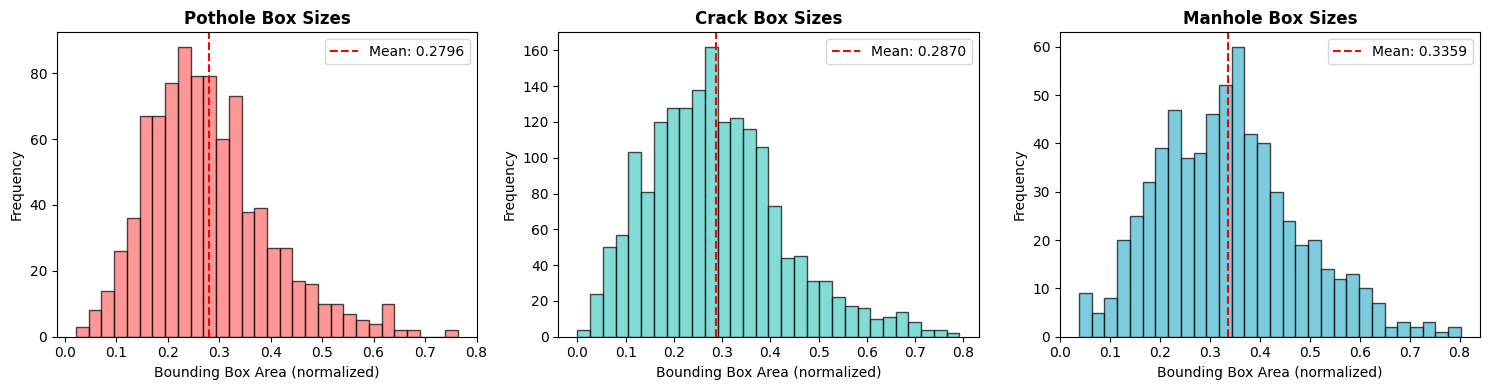


💾 Saved: bbox_size_distribution.png


In [13]:
# Visualize bounding box size distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (class_id, sizes) in enumerate(bbox_sizes.items()):
    if sizes:
        ax = axes[idx]
        ax.hist(sizes, bins=30, color=colors[idx], edgecolor='black', alpha=0.7)
        ax.set_xlabel('Bounding Box Area (normalized)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{CLASS_NAMES[class_id]} Box Sizes', fontsize=12, fontweight='bold')
        ax.axvline(np.mean(sizes), color='red', linestyle='--', label=f'Mean: {np.mean(sizes):.4f}')
        ax.legend()

plt.tight_layout()
plt.savefig(f"{CONFIG['working_dir']}/bbox_size_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: bbox_size_distribution.png")

In [ ]:
# # WRONG CODE
# def visualize_sample_with_bbox(image_path, label_path, class_names, ax=None):
#     """
#     Visualize an image with its bounding boxes.
#     """
#     # Load image
#     img = Image.open(image_path)
#     img_width, img_height = img.size
    
#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
#     ax.imshow(img)
    
#     # Parse and draw bounding boxes
#     colors_map = {0: 'red', 1: 'blue', 2: 'green'}
    
#     if label_path.exists():
#         with open(label_path, 'r') as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) >= 5:
#                     class_id = int(parts[0])
#                     x_center = float(parts[1]) * img_width
#                     y_center = float(parts[2]) * img_height
#                     width = float(parts[3]) * img_width
#                     height = float(parts[4]) * img_height
                    
#                     # Convert to corner coordinates
#                     x1 = x_center - width / 2
#                     y1 = y_center - height / 2
                    
#                     # Draw rectangle
#                     rect = patches.Rectangle((x1, y1), width, height,
#                                             linewidth=2, edgecolor=colors_map.get(class_id, 'yellow'),
#                                             facecolor='none')
#                     ax.add_patch(rect)
                    
#                     # Add label
#                     ax.text(x1, y1 - 5, class_names.get(class_id, f'Class {class_id}'),
#                            color='white', fontsize=10, fontweight='bold',
#                            bbox=dict(boxstyle='round', facecolor=colors_map.get(class_id, 'yellow'), alpha=0.8))
    
#     ax.axis('off')
#     ax.set_title(Path(image_path).name, fontsize=10)
#     return ax

In [ ]:
def visualize_sample_with_bbox(image_path, label_path, class_names, ax=None):
    img = Image.open(image_path)
    img_width, img_height = img.size
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    ax.imshow(img)
    colors_map = {0: 'red', 1: 'blue', 2: 'green'}
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    # Standard YOLO format: class cx cy w h
                    class_id = int(parts[0])
                    x_center = float(parts[1]) * img_width
                    y_center = float(parts[2]) * img_height
                    width = float(parts[3]) * img_width
                    height = float(parts[4]) * img_height
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                elif len(parts) > 5:
                    # Polygon format: class x1 y1 x2 y2 x3 y3 x4 y4 ...
                    class_id = int(parts[0])
                    coords = [float(x) for x in parts[1:]]
                    xs = [coords[i] * img_width for i in range(0, len(coords), 2)]
                    ys = [coords[i] * img_height for i in range(1, len(coords), 2)]
                    x1 = min(xs)
                    y1 = min(ys)
                    width = max(xs) - x1
                    height = max(ys) - y1
                else:
                    continue
                    
                # Draw rectangle
                rect = patches.Rectangle((x1, y1), width, height,
                                        linewidth=2, edgecolor=colors_map.get(class_id, 'yellow'),
                                        facecolor='none')
                ax.add_patch(rect)
                
                # Add label
                ax.text(x1, y1 - 5, class_names.get(class_id, f'Class {class_id}'),
                       color='white', fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor=colors_map.get(class_id, 'yellow'), alpha=0.8))
    
    ax.axis('off')
    ax.set_title(Path(image_path).name, fontsize=10)
    return ax

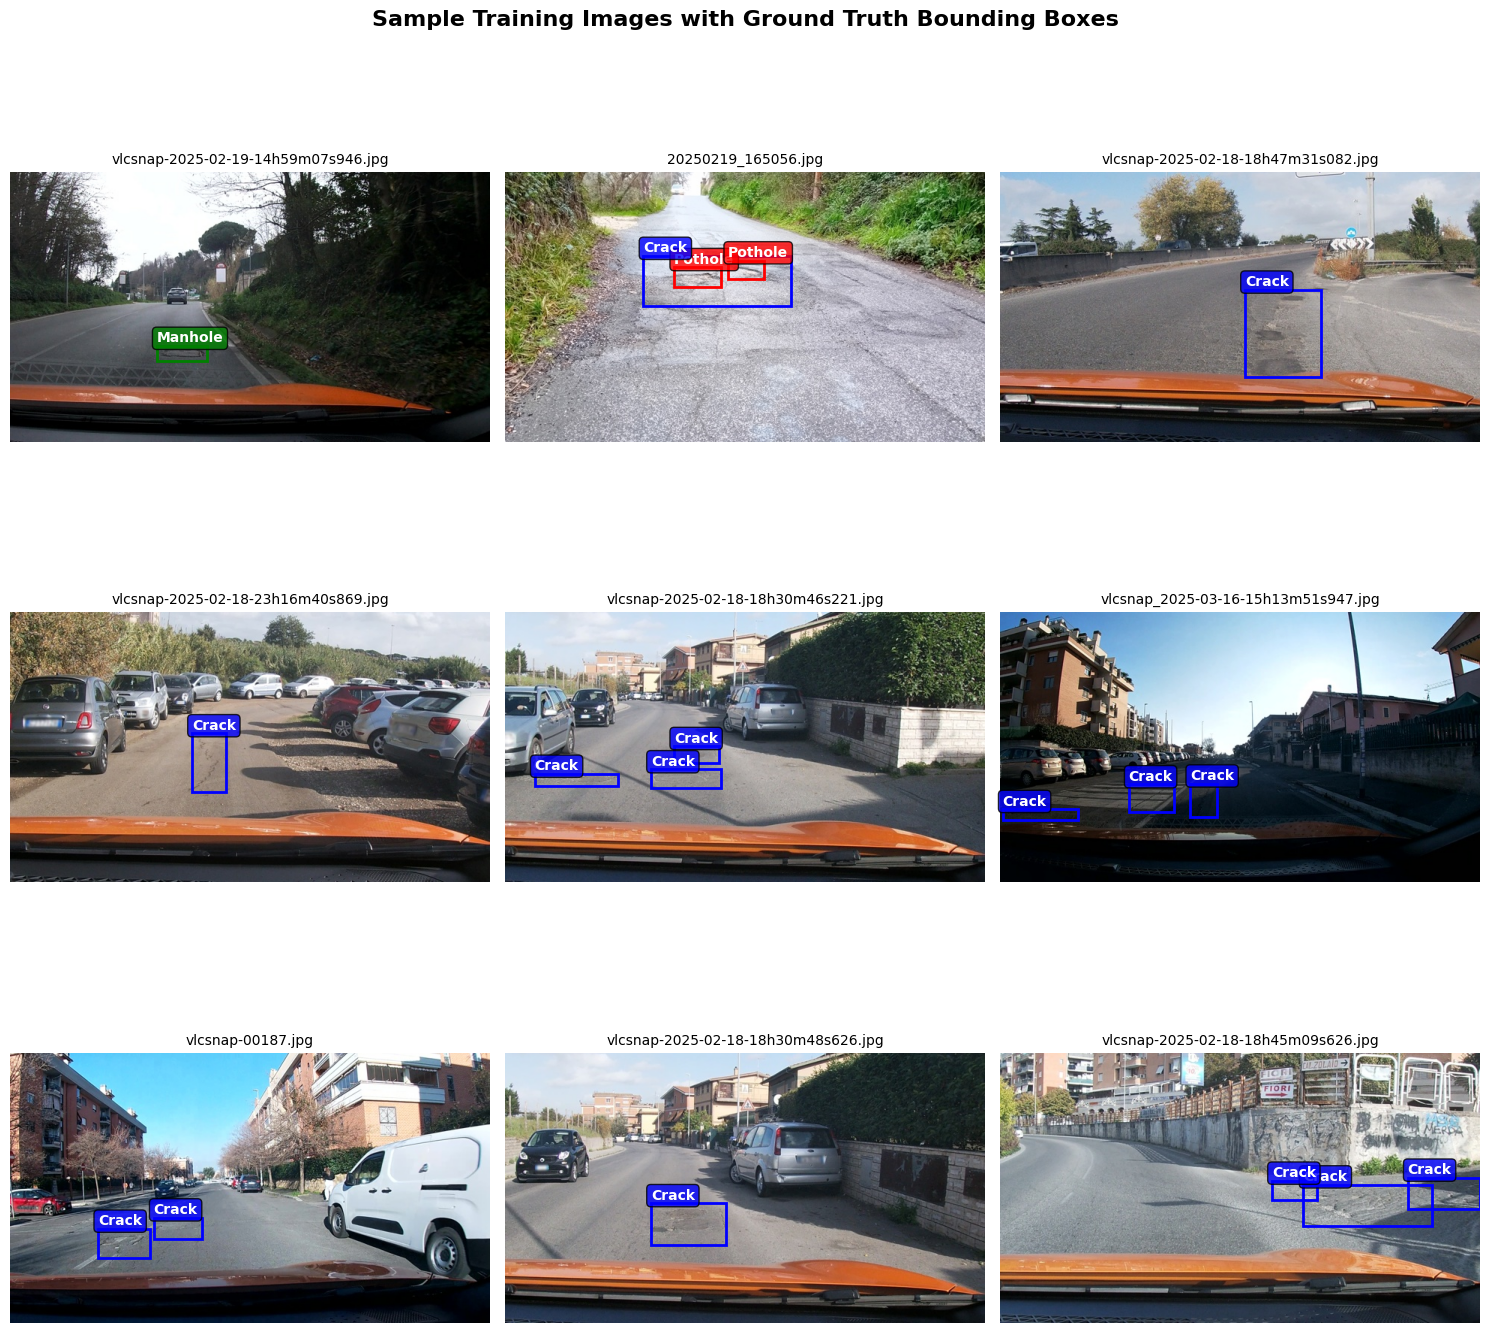


💾 Saved: sample_training_images.png


In [ ]:
# Display sample images with bounding boxes
train_images_dir = subset_path / 'train' / 'images'
train_labels_dir = subset_path / 'train' / 'labels'

sample_images = list(train_images_dir.glob('*'))[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    label_path = train_labels_dir / (img_path.stem + '.txt')
    visualize_sample_with_bbox(img_path, label_path, CLASS_NAMES, axes[idx])

plt.suptitle('Sample Training Images with Ground Truth Bounding Boxes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['working_dir']}/sample_training_images.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: sample_training_images.png")

---
## 4. Model Training with Auto-Save <a id='4-model-training'></a>

Training YOLOv with checkpoint saving every 5 epochs for safety.

### yolo12n

In [17]:
# Initialize YOLO model
model_name = "yolo12n"
print(f"🔄 Loading {model_name} pre-trained model...")

model_twelve_n = YOLO(f'{model_name}.pt')

print(f"✅ Model loaded successfully!")
print(f"\n📋 Model Info:")
print(f"   Architecture: {model_name}")
print(f"   Pre-trained on: COCO dataset")

🔄 Loading yolo12n pre-trained model...
✅ Model loaded successfully!

📋 Model Info:
   Architecture: yolo12n
   Pre-trained on: COCO dataset


In [18]:
# Training configuration with auto-save
print("\n" + "="*60)
print("🚀 STARTING TRAINING")
print("="*60)
print(f"\n📋 Training Configuration:")
print(f"   Model: {model_name}")
print(f"   Image Size: {CONFIG['image_size']}")
print(f"   Batch Size: {CONFIG['batch_size']}")
print(f"   Epochs: {CONFIG['epochs']}")
print(f"   Auto-save every: {CONFIG['save_period']} epochs")
print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
print("\n" + "-"*60 + "\n")

# Train the model
results = model_twelve_n.train(
    data=str(yaml_path),
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['image_size'],
    batch=CONFIG['batch_size'],
    device=CONFIG['device'],
    
    # Auto-save configuration
    save=True,
    save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
    # Training settings
    patience=15,  # Early stopping patience
    lr0=0.01,  # Initial learning rate
    lrf=0.01,  # Final learning rate factor
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    
    # Augmentation
    
    # Output settings
    project=CONFIG['working_dir'],
    name=f'road_damage_{model_name}',
    exist_ok=True,
    plots=True,
    verbose=True
)

print("\n" + "="*60)
print("✅ TRAINING COMPLETED!")
print("="*60)


🚀 STARTING TRAINING

📋 Training Configuration:
   Model: yolo12n
   Image Size: 640
   Batch Size: 16
   Epochs: 100
   Auto-save every: -1 epochs
   Dataset: 60% subset (1406 training images)

------------------------------------------------------------

Ultralytics 8.4.171 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/road_damage_subset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:677: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      1.81G       2.41      3.068      1.776         19        640: 100% ━━━━━━━━━━━━ 88/88 5.5it/s 15.9s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 8.6it/s 1.5s0.1s
                   all        401        915      0.208      0.232      0.153     0.0532

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      1.83G       2.46      2.882      1.793         38        640: 100% ━━━━━━━━━━━━ 88/88 5.4it/s 16.2s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 9.0it/s 1.4s0.1s
                   all        401        915      0.191      0.289      0.169     0.0575

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      1.85G      2.411      2.652      1.787         26        640: 10

In [19]:
# Display training results location
train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

print("📁 Training outputs saved at:")
print(f"   {train_dir}")
print("\n📄 Important files:")

important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
                   'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

for f in important_files:
    file_path = train_dir / f
    status = "✅" if file_path.exists() else "❌"
    print(f"   {status} {f}")

📁 Training outputs saved at:
   /kaggle/working/road_damage_yolo12n

📄 Important files:
   ✅ weights/best.pt
   ✅ weights/last.pt
   ✅ results.png
   ✅ confusion_matrix.png
   ❌ F1_curve.png
   ❌ PR_curve.png
   ❌ P_curve.png
   ❌ R_curve.png


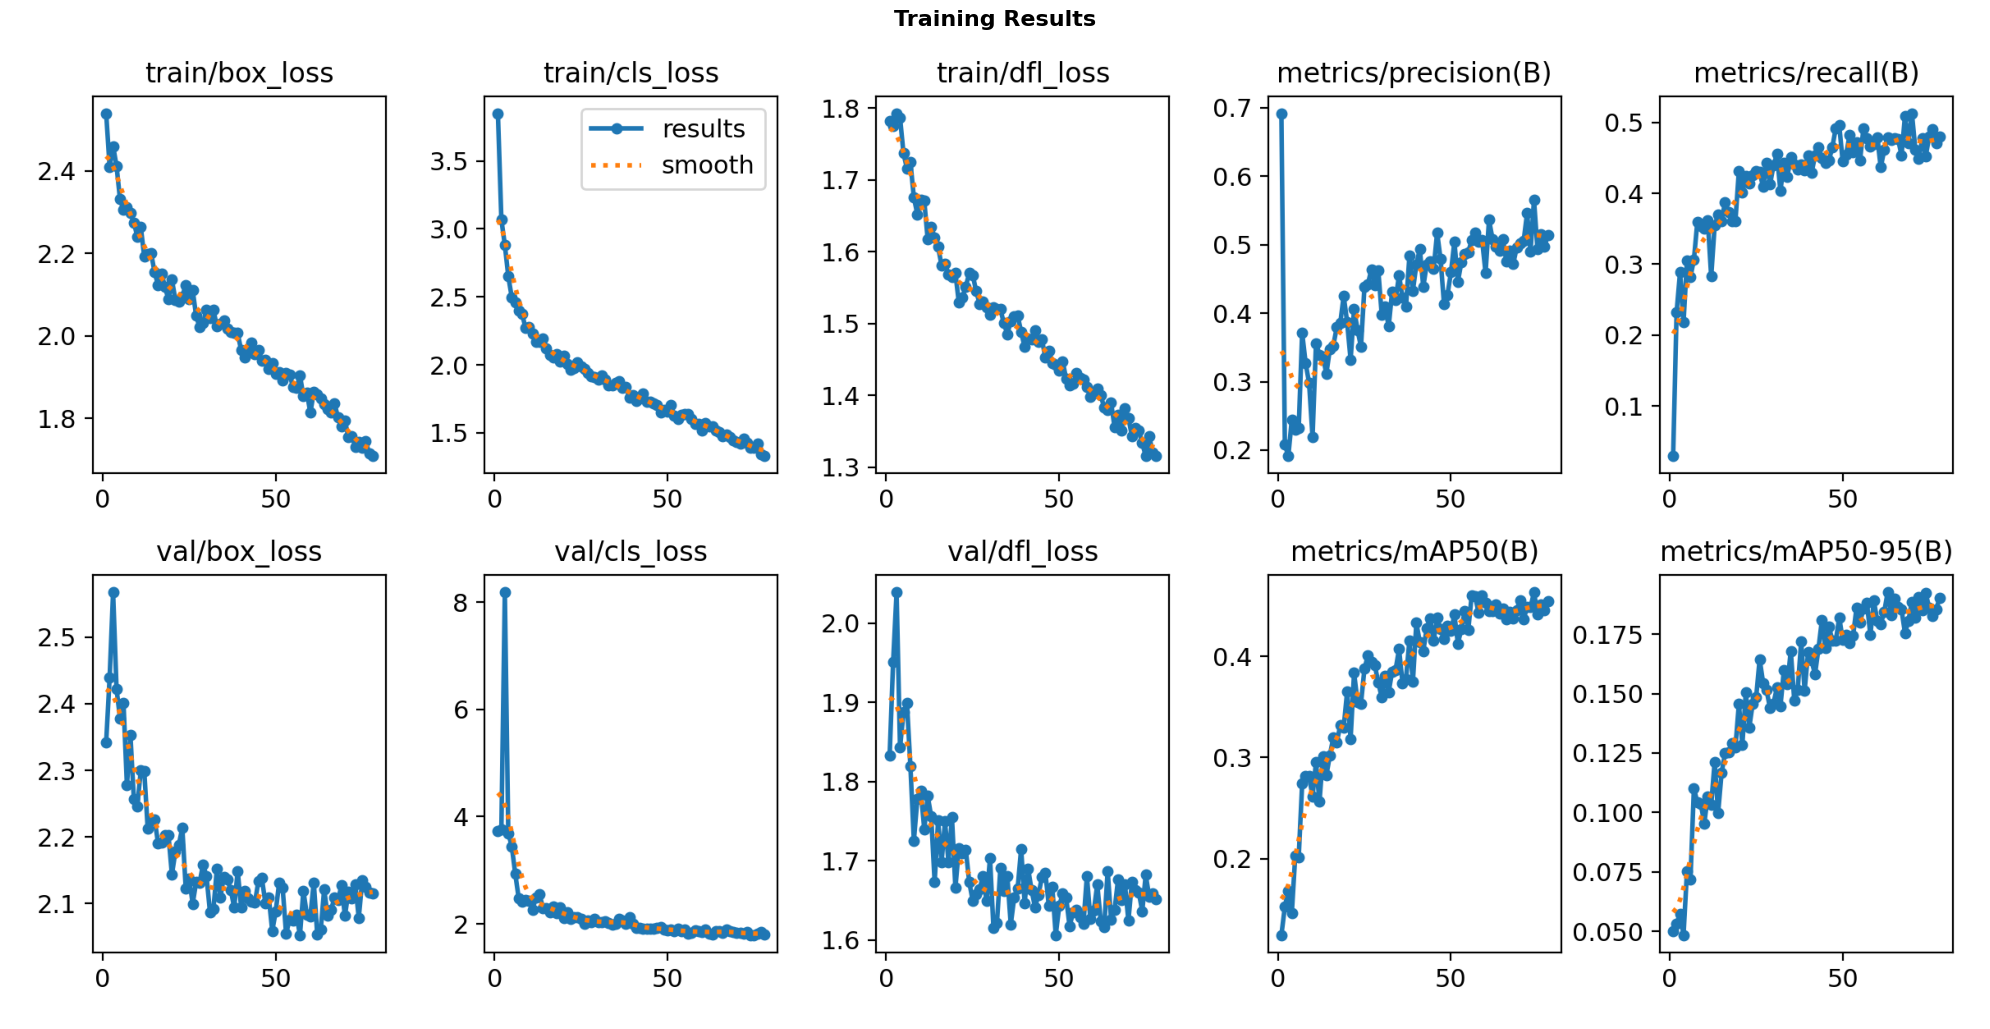

In [20]:
# Display training curves
results_img = train_dir / 'results.png'
if results_img.exists():
    img = Image.open(results_img)
    plt.figure(figsize=(20, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Training results image not found.")

---
## 5. Evaluation & Metrics <a id='5-evaluation--metrics'></a>

In [21]:
# Load the best model
best_model_path = train_dir / 'weights' / 'best.pt'

if best_model_path.exists():
    best_model_twelve_n = YOLO(str(best_model_path))
    print(f"✅ Loaded best model from: {best_model_path}")
else:
    print("⚠️ Best model not found. Using last trained model.")
    best_model_twelve_n = model_twelve_n

✅ Loaded best model from: /kaggle/working/road_damage_yolo12n/weights/best.pt


In [22]:
# Evaluate on validation set
print("\n" + "="*60)
print("📊 VALIDATION SET EVALUATION")
print("="*60 + "\n")

val_results = best_model_twelve_n.val(
    data=str(yaml_path),
    split='val',
    verbose=True,
    plots=True
)


📊 VALIDATION SET EVALUATION

Ultralytics 8.4.171 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2609.7±690.1 MB/s, size: 100.9 KB)
val: Scanning /kaggle/working/road_damage_subset/val/labels.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 186.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 7.0it/s 3.7s0.1s
                   all        401        915      0.496       0.48      0.452      0.193
               Pothole        156        238      0.423      0.345      0.353      0.142
                 Crack        272        486      0.478      0.327      0.342      0.136
               Manhole        158        191      0.587       0.77      0.663        0.3
Speed: 0.9ms preprocess, 3.6ms inference, 0.0ms loss, 1.4ms postprocess per image


In [ ]:
# Evaluate on test set
print("\n" + "="*60)
print("📊 TEST SET EVALUATION")
print("="*60 + "\n")

test_results = best_model_twelve_n.val(
    data=str(yaml_path),
    split='test',
    verbose=True,
    plots=True,
    project=CONFIG['working_dir'],
)


📊 TEST SET EVALUATION

Ultralytics 8.4.171 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2109.9±439.3 MB/s, size: 85.8 KB)
val: Scanning /kaggle/working/road_damage_subset/test/labels... 202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202 1.1Kit/s 0.2s<0.3s
val: New cache created: /kaggle/working/road_damage_subset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 5.5it/s 2.3s0.1s
                   all        202        476       0.49      0.496      0.486      0.217
               Pothole         84        130      0.391      0.331      0.329      0.115
                 Crack        138        242      0.455      0.339      0.335      0.142
               Manhole         85        104      0.625      0.817      0.795      0.394
Speed: 1.3ms p

In [24]:
# Extract and display detailed metrics
print("\n" + "="*70)
print("📈 DETAILED EVALUATION METRICS")
print("="*70)

# Overall metrics
print("\n🎯 Overall Performance (Test Set):")
print("-" * 50)
print(f"   mAP@0.5:        {test_results.box.map50:.4f}  ({test_results.box.map50*100:.2f}%)")
print(f"   mAP@0.5:0.95:   {test_results.box.map:.4f}  ({test_results.box.map*100:.2f}%)")
print(f"   Precision:      {test_results.box.mp:.4f}  ({test_results.box.mp*100:.2f}%)")
print(f"   Recall:         {test_results.box.mr:.4f}  ({test_results.box.mr*100:.2f}%)")

# Per-class metrics
print("\n📋 Per-Class Performance:")
print("-" * 70)
print(f"{'Class':<15} {'Precision':>12} {'Recall':>12} {'mAP@0.5':>12} {'mAP@0.5:0.95':>15}")
print("-" * 70)

for i, class_name in CLASS_NAMES.items():
    if i < len(test_results.box.ap50):
        p = test_results.box.p[i] if hasattr(test_results.box, 'p') and i < len(test_results.box.p) else 0
        r = test_results.box.r[i] if hasattr(test_results.box, 'r') and i < len(test_results.box.r) else 0
        ap50 = test_results.box.ap50[i] if i < len(test_results.box.ap50) else 0
        ap = test_results.box.ap[i] if i < len(test_results.box.ap) else 0
        
        print(f"{class_name:<15} {p:>11.4f} {r:>12.4f} {ap50:>12.4f} {ap:>15.4f}")

print("-" * 70)


📈 DETAILED EVALUATION METRICS

🎯 Overall Performance (Test Set):
--------------------------------------------------
   mAP@0.5:        0.4862  (48.62%)
   mAP@0.5:0.95:   0.2171  (21.71%)
   Precision:      0.4901  (49.01%)
   Recall:         0.4958  (49.58%)

📋 Per-Class Performance:
----------------------------------------------------------------------
Class              Precision       Recall      mAP@0.5    mAP@0.5:0.95
----------------------------------------------------------------------
Pothole              0.3912       0.3311       0.3286          0.1146
Crack                0.4546       0.3388       0.3346          0.1425
Manhole              0.6247       0.8173       0.7952          0.3943
----------------------------------------------------------------------


In [25]:
# Create metrics summary table
metrics_data = {
    'Metric': ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Validation': [
        f"{val_results.box.map50:.4f}",
        f"{val_results.box.map:.4f}",
        f"{val_results.box.mp:.4f}",
        f"{val_results.box.mr:.4f}"
    ],
    'Test': [
        f"{test_results.box.map50:.4f}",
        f"{test_results.box.map:.4f}",
        f"{test_results.box.mp:.4f}",
        f"{test_results.box.mr:.4f}"
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("\n📊 Metrics Comparison Table:")
print(metrics_df.to_string(index=False))

# Save metrics to CSV
metrics_df.to_csv(f"{CONFIG['working_dir']}/evaluation_metrics.csv", index=False)
print(f"\n💾 Saved: evaluation_metrics.csv")


📊 Metrics Comparison Table:
      Metric Validation   Test
     mAP@0.5     0.4523 0.4862
mAP@0.5:0.95     0.1926 0.2171
   Precision     0.4960 0.4901
      Recall     0.4804 0.4958

💾 Saved: evaluation_metrics.csv


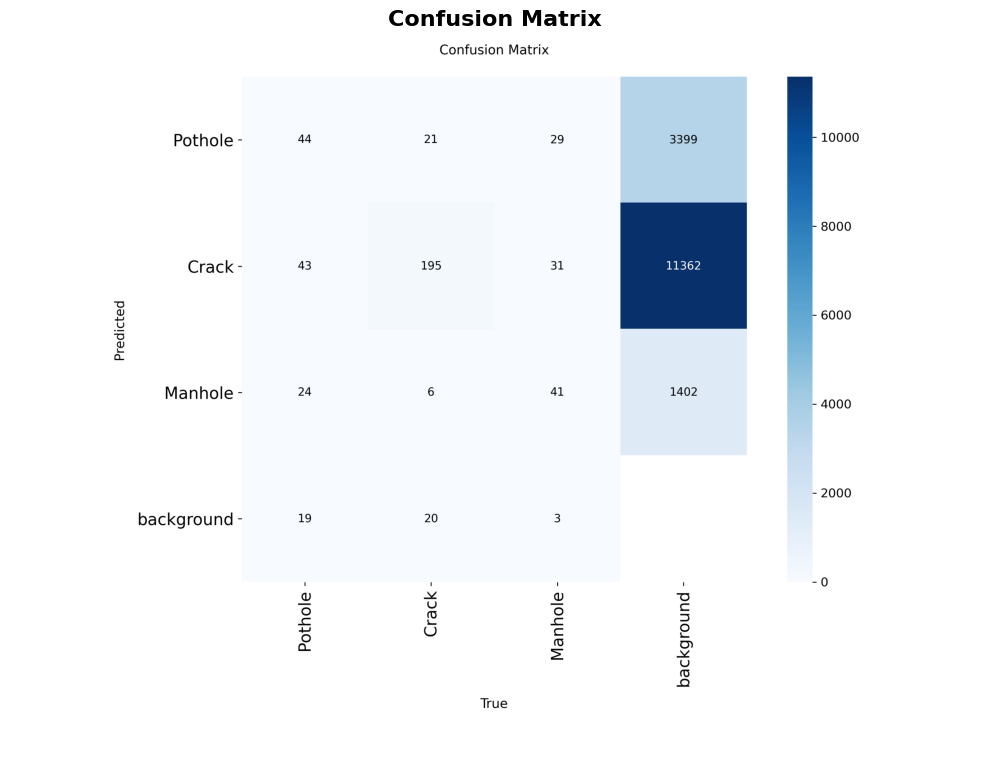

In [30]:
# Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'
confusion_matrix_path = test_results.save_dir / 'confusion_matrix.png'

if confusion_matrix_path.exists():
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    img = Image.open(confusion_matrix_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Confusion matrix not found.")

In [ ]:
# Display PR and F1 curves
"""
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

curve_files = [
    ('PR_curve.png', 'Precision-Recall Curve'),
    ('F1_curve.png', 'F1 Score Curve'),
    ('P_curve.png', 'Precision Curve'),
    ('R_curve.png', 'Recall Curve')
]

for idx, (filename, title) in enumerate(curve_files):
    ax = axes[idx // 2, idx % 2]
    curve_path = train_dir / filename
    
    if curve_path.exists():
        img = Image.open(curve_path)
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{filename} not found', ha='center', va='center')
    ax.axis('off')

plt.suptitle('Evaluation Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['working_dir']}/evaluation_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: evaluation_curves.png")
"""

### YOLO11n

In [ ]:
# # Initialize YOLO model
# model_name = "yolo11n"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eleven_n = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eleven_n.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eleven_n = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eleven_n = model_eleven_n

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eleven_n.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eleven_n.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### YOLO10n

In [ ]:
# # Initialize YOLO model
# model_name = "yolov10n"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_ten_n = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_ten_n.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_ten_n = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_ten_n = model_ten_n

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_ten_n.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_ten_n.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### YOLO8n

In [ ]:
# # Initialize YOLO model
# model_name = "yolov8n"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eight_n = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eight_n.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eight_n = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eight_n = model_eight_n

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eight_n.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eight_n.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo12s

In [ ]:
# # Initialize YOLO model
# model_name = "yolo12s"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_twelve_s = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_twelve_s.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_twelve_s = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_twelve_s = model_twelve_s

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_twelve_s.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_twelve_s.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo11s

In [ ]:
# # Initialize YOLO model
# model_name = "yolo11s"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eleven_s = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eleven_s.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eleven_s = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eleven_s = model_eleven_s

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eleven_s.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eleven_s.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo10s

In [ ]:
# # Initialize YOLO model
# model_name = "yolov10s"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_ten_s = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_ten_s.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_ten_s = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_ten_s = model_ten_s

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_ten_s.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_ten_s.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo8s

In [ ]:
# # Initialize YOLO model
# model_name = "yolov8s"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eight_s = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eight_s.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eight_s = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eight_s = model_eight_s

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eight_s.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eight_s.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo12m

In [ ]:
# # Initialize YOLO model
# model_name = "yolo12m"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_twelve_m = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_twelve_m.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_twelve_m = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_twelve_m = model_twelve_m

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_twelve_m.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_twelve_m.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo11m

In [ ]:
# # Initialize YOLO model
# model_name = "yolo11m"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eleven_m = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eleven_m.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eleven_m = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eleven_m = model_eleven_m

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eleven_m.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eleven_m.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo10m

In [ ]:
# # Initialize YOLO model
# model_name = "yolov10m"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_ten_m = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_ten_m.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_ten_m = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_ten_m = model_ten_m

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_ten_m.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_ten_m.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo8m

In [ ]:
# # Initialize YOLO model
# model_name = "yolov8m"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eight_m = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eight_m.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eight_m = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eight_m = model_eight_m

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eight_m.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eight_m.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo12l

In [ ]:
# # Initialize YOLO model (for RESUME)
# model_name = "yolo12l"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_twelve_l = YOLO(f'{model_name}.pt') # RESUME YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_twelve_l.train(
#     resume = True,   # RESUME RESUME RESUME
    
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_twelve_l = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_twelve_l = model_twelve_l

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_twelve_l.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_twelve_l.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo11l

In [ ]:
# # Initialize YOLO model
# model_name = "yolo11l"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eleven_l = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eleven_l.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eleven_l = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eleven_l = model_eleven_l

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eleven_l.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eleven_l.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo10l

In [ ]:
# # Initialize YOLO model
# model_name = "yolov10l"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_ten_l = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_ten_l.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_ten_l = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_ten_l = model_ten_l

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_ten_l.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_ten_l.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo8l

In [ ]:
# # Initialize YOLO model
# model_name = "yolov8l"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eight_l = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eight_l.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eight_l = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eight_l = model_eight_l

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eight_l.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eight_l.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo12x

In [ ]:
# # Initialize YOLO model
# model_name = "yolo12x"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_twelve_x = YOLO(f'{model_name}.pt') # RESUME YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_twelve_x.train(
#     #resume=True,
    
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_twelve_x = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_twelve_x = model_twelve_x

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_twelve_x.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_twelve_x.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo11x

In [ ]:
# # Initialize YOLO model
# model_name = "yolo11x"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eleven_x = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eleven_x.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eleven_x = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eleven_x = model_eleven_x

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eleven_x.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eleven_x.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo10x

In [ ]:
# # Initialize YOLO model
# model_name = "yolov10x"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_ten_x = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_ten_x.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_ten_x = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_ten_x = model_ten_x

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_ten_x.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_ten_x.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

### yolo8x

In [ ]:
# # Initialize YOLO model
# model_name = "yolov8x"
# print(f"🔄 Loading {model_name} pre-trained model...")

# model_eight_x = YOLO(f'{model_name}.pt')

# print(f"✅ Model loaded successfully!")
# print(f"\n📋 Model Info:")
# print(f"   Architecture: {model_name}")
# print(f"   Pre-trained on: COCO dataset")

In [ ]:
# # Training configuration with auto-save
# print("\n" + "="*60)
# print("🚀 STARTING TRAINING")
# print("="*60)
# print(f"\n📋 Training Configuration:")
# print(f"   Model: {model_name}")
# print(f"   Image Size: {CONFIG['image_size']}")
# print(f"   Batch Size: {CONFIG['batch_size']}")
# print(f"   Epochs: {CONFIG['epochs']}")
# print(f"   Auto-save every: {CONFIG['save_period']} epochs")
# print(f"   Dataset: 60% subset ({dataset_stats.get('train', 'N/A')} training images)")
# print("\n" + "-"*60 + "\n")

# # Train the model
# results = model_eight_x.train(
#     data=str(yaml_path),
#     epochs=CONFIG['epochs'],
#     imgsz=CONFIG['image_size'],
#     batch=CONFIG['batch_size'],
#     device=CONFIG['device'],
    
#     # Auto-save configuration
#     save=True,
#     save_period=CONFIG['save_period'],  # Save checkpoint every N epochs
    
#     # Training settings
#     patience=15,  # Early stopping patience
#     lr0=0.01,  # Initial learning rate
#     lrf=0.01,  # Final learning rate factor
#     momentum=0.937,
#     weight_decay=0.0005,
#     warmup_epochs=3,
#     warmup_momentum=0.8,
    
#     # Augmentation
    
#     # Output settings
#     project=CONFIG['working_dir'],
#     name=f'road_damage_{model_name}',
#     exist_ok=True,
#     plots=True,
#     verbose=True
# )

# print("\n" + "="*60)
# print("✅ TRAINING COMPLETED!")
# print("="*60)

In [ ]:
# # Display training results location
# train_dir = Path(CONFIG['working_dir']) / f'road_damage_{model_name}'

# print("📁 Training outputs saved at:")
# print(f"   {train_dir}")
# print("\n📄 Important files:")

# important_files = ['weights/best.pt', 'weights/last.pt', 'results.png', 'confusion_matrix.png', 
#                    'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']

# for f in important_files:
#     file_path = train_dir / f
#     status = "✅" if file_path.exists() else "❌"
#     print(f"   {status} {f}")

In [ ]:
# # Load the best model
# best_model_path = train_dir / 'weights' / 'best.pt'

# if best_model_path.exists():
#     best_model_eight_x = YOLO(str(best_model_path))
#     print(f"✅ Loaded best model from: {best_model_path}")
# else:
#     print("⚠️ Best model not found. Using last trained model.")
#     best_model_eight_x = model_eight_x

In [ ]:
# # Evaluate on validation set
# print("\n" + "="*60)
# print("📊 VALIDATION SET EVALUATION")
# print("="*60 + "\n")

# val_results = best_model_eight_x.val(
#     data=str(yaml_path),
#     split='val',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Evaluate on test set
# print("\n" + "="*60)
# print("📊 TEST SET EVALUATION")
# print("="*60 + "\n")

# test_results = best_model_eight_x.val(
#     data=str(yaml_path),
#     split='test',
#     verbose=True,
#     plots=True
# )

In [ ]:
# # Display confusion matrix
# confusion_matrix_path = train_dir / 'confusion_matrix.png'

# if confusion_matrix_path.exists():
#     fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#     img = Image.open(confusion_matrix_path)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ Confusion matrix not found.")

## END?

---
## 6. Predictions with Bounding Boxes <a id='6-predictions-with-bounding-boxes'></a>

Visualizing model predictions on test images with detailed metrics.